In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 16
Total threads: 128,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45197,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33081,Total threads: 8
Dashboard: http://127.0.0.1:40133/status,Memory: 62.93 GiB
Nanny: tcp://127.0.0.1:41267,


### Load MITgcm Output from Assimilations

In [2]:
foldername = '/home/edavenport/analysis/TPOSE6_VelocityAssim/TPOSE_TAO/OSM_2026/'

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [4]:
from xmitgcm import open_mdsdataset
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

prefix = ['diag_state','diag_surf']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-01-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

In [60]:
lon_str = '110'

### Checking if U and V have oscillatory relationship

In [61]:
TAO_ADCP_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO = xr.open_dataset(TAO_ADCP_file)
dsTAO['depth'] = -1*dsTAO.depth
dsTAO['u_1205'] = dsTAO.u_1205/100 # convert from cm/s to m/s
dsTAO['v_1206'] = dsTAO.v_1206/100 # convert from cm/s to m/s
dsTAO = dsTAO.rename({'depth':'Z','lat':'YC','lon':'XC'})

In [62]:
dsTAO = dsTAO.sel(time=slice('2012-01-01','2013-12-31'))

In [63]:
dsTAO_mini = dsTAO.sel(time=slice('2013-02-15','2013-08-15')) # subset to sep 2012, apr 2013
# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC

In [64]:
u = dsTAO_mini.u_1205 - dsTAO_mini.u_1205.mean(dim='time') # take the anomaly from the mean over the 2 year time series
v = dsTAO_mini.v_1206 - dsTAO_mini.v_1206.mean(dim='time') # take the anomaly from the mean over the 2 year time series

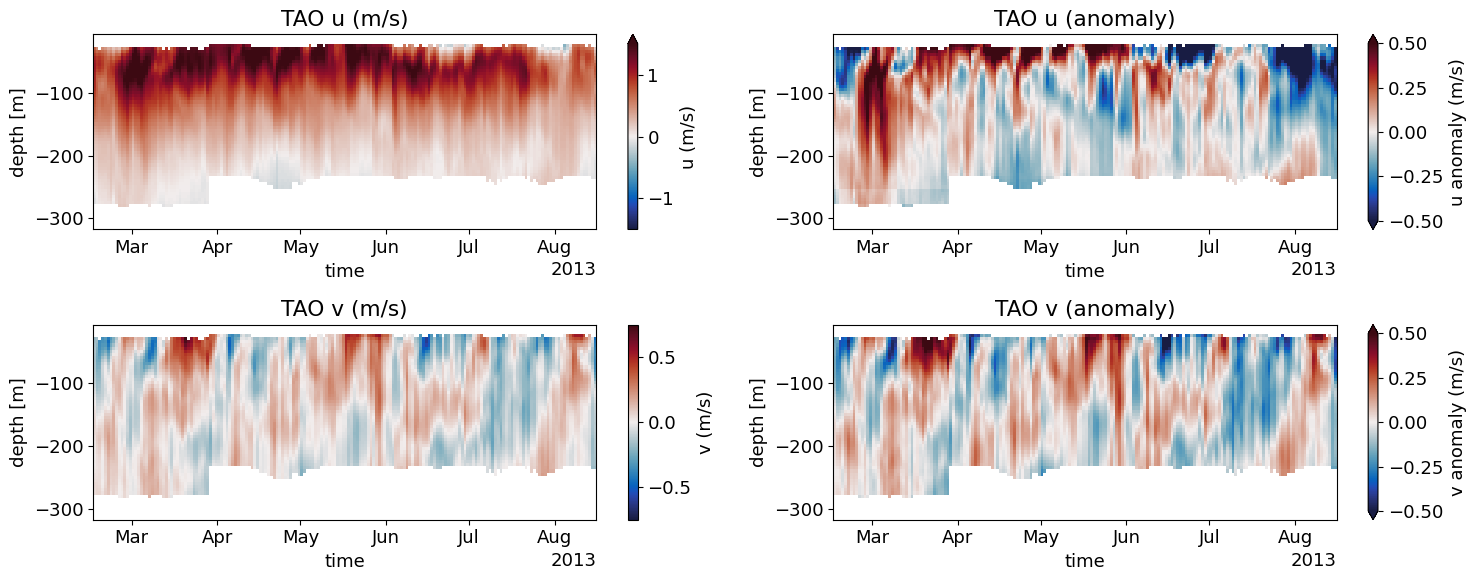

In [65]:
fig, ax = plt.subplots(figsize=(15,6),nrows=2, ncols=2)
dsTAO_mini.u_1205.plot(ax=ax[0,0],x='time',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label':'u (m/s)'})
dsTAO_mini.v_1206.plot(ax=ax[1,0],x='time',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label':'v (m/s)'})
u.plot(ax=ax[0,1],cmap=cmo.balance,x='time',vmin=-0.5,vmax=0.5,cbar_kwargs={'label':'u anomaly (m/s)'})
v.plot(ax=ax[1,1],cmap=cmo.balance,x='time',vmin=-0.5,vmax=0.5,cbar_kwargs={'label':'v anomaly (m/s)'})
ax[0,0].set_title('TAO u (m/s)')
ax[1,0].set_title('TAO v (m/s)')
ax[0,1].set_title('TAO u (anomaly)')
ax[1,1].set_title('TAO v (anomaly)')
plt.tight_layout() 
fig.savefig(foldername + 'TAO_u_v_spring_' + lon_str + '.png',dpi=300)

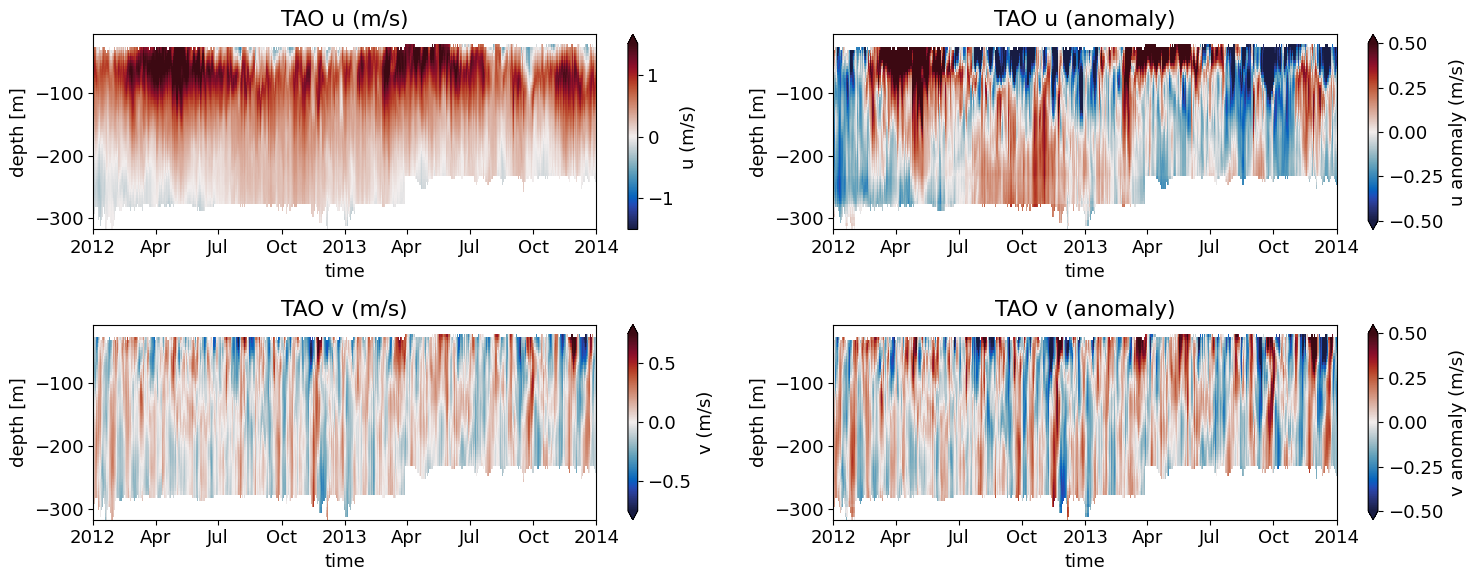

In [66]:
u = dsTAO.u_1205 - dsTAO.u_1205.mean(dim='time') # take the anomaly from the mean over the 2 year time series
v = dsTAO.v_1206 - dsTAO.v_1206.mean(dim='time') # take the anomaly from the mean over the 2 year time series

fig, ax = plt.subplots(figsize=(15,6),nrows=2, ncols=2)
dsTAO.u_1205.plot(ax=ax[0,0],x='time',cmap=cmo.balance,vmin=-1.5,vmax=1.5,cbar_kwargs={'label':'u (m/s)'})
dsTAO.v_1206.plot(ax=ax[1,0],x='time',cmap=cmo.balance,vmin=-0.75,vmax=0.75,cbar_kwargs={'label':'v (m/s)'})
u.plot(ax=ax[0,1],cmap=cmo.balance,x='time',vmin=-0.5,vmax=0.5,cbar_kwargs={'label':'u anomaly (m/s)'})
v.plot(ax=ax[1,1],cmap=cmo.balance,x='time',vmin=-0.5,vmax=0.5,cbar_kwargs={'label':'v anomaly (m/s)'})
ax[0,0].set_title('TAO u (m/s)')
ax[1,0].set_title('TAO v (m/s)')
ax[0,1].set_title('TAO u (anomaly)')
ax[1,1].set_title('TAO v (anomaly)')
plt.tight_layout() 
fig.savefig(foldername + 'TAO_u_v_2012_2013_' + lon_str + '.png',dpi=300)

### Low Pass Filter then Repeat (looking for u and v in quadrature during this spring variability)

In [67]:
from scipy.signal import butter, sosfiltfilt, detrend

# filtering out high frequency changes
fs = 1/86400 # sampling rate is 1 hour (86400 seconds per hour)
highF = (1/10)*fs #  (1 cycle /10 days) * (1 day/86400 second)
lowF = (1/100)*fs #  (1 cycle /100 days) * (1 day/86400 second)
cutoff = np.array([lowF, highF])
order = 4
sos = butter(order, cutoff, 'bandpass', fs=fs, output='sos')

# set nan to be 0 for filtering, then set back to nan after
dsTAO_filled = dsTAO.fillna(0)

uvel_bandpass = sosfiltfilt(sos, detrend(dsTAO_filled.u_1205.squeeze(),axis=0), axis=0)
vvel_bandpass = sosfiltfilt(sos, detrend(dsTAO_filled.v_1206.squeeze(),axis=0), axis=0)

temp = dsTAO.u_1205.squeeze().copy(deep=True) 
temp.data = uvel_bandpass  
uvel_bandpass = temp

temp = dsTAO.v_1206.squeeze().copy(deep=True)
temp.data = vvel_bandpass
vvel_bandpass = temp

In [68]:
vvel_bandpass

<xarray.DataArray 'v_1206' (time: 731, Z: 62)> Size: 363kB
array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         2.39543171e-03,  2.32985857e-03,  3.71505543e-03],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         5.08845271e-04,  9.19552350e-04,  2.27590472e-03],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.51716862e-03, -7.22754502e-04,  6.05899384e-04],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -2.80081492e-06, -2.27014910e-06,  6.32398442e-07],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -2.96875663e-06, -2.75756493e-06,  5.25506310e-07],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -3.10174678e-06, -3.20147514e-06,  4.16970370e-07]],
      shape=(731, 62))
Coordinates:
  * time     (time) datetime64[ns] 6kB 2012-01-01T12:00:00 ... 2013-12-31T12:...
  * Z        (Z) float32 248B -10.0 -15.0 -20.0 -25.0 ... -305.0 -310.0 -315.0
    YC       float32 4B 0.0
    XC       float32 4B 250.0
Attributes:
    name:            v
    long_name:       Northward Velocity
    generic_name:    v
    FORTRAN_format:   
    units:           cm/s
    epic_code:       1206

/tmp/ipykernel_385606/3298758631.py:5: RuntimeWarning: divide by zero encountered in divide
  plt.loglog(1/(f*86400), Pxx, label='u')
/tmp/ipykernel_385606/3298758631.py:7: RuntimeWarning: divide by zero encountered in divide
  plt.loglog(1/(f*86400), Pxx, label='v')


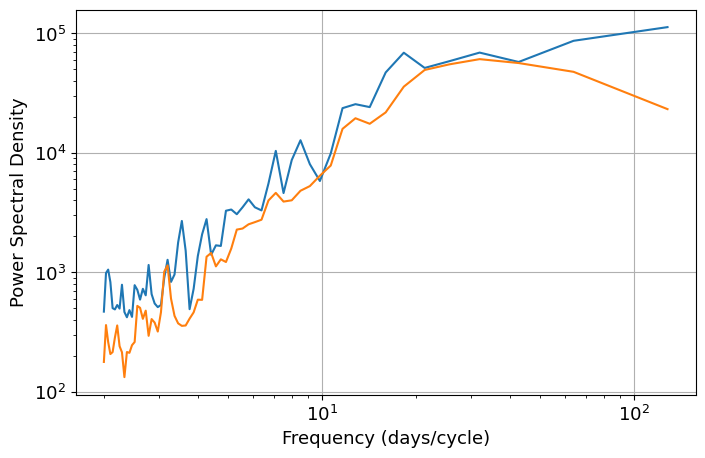

In [69]:
# look at the speectrum of the filtered signal
from scipy.signal import welch
f, Pxx = welch(dsTAO_filled.u_1205.squeeze()[:,10], fs=fs, nperseg=128, detrend='linear')
plt.figure(figsize=(8,5))
plt.loglog(1/(f*86400), Pxx, label='u')
f, Pxx = welch(dsTAO_filled.v_1206.squeeze()[:,10], fs=fs, nperseg=128, detrend='linear')
plt.loglog(1/(f*86400), Pxx, label='v')
plt.xlabel('Frequency (days/cycle)')
plt.ylabel('Power Spectral Density')
plt.title('')
# plt.axvline(45, color='r', linestyle='--', label='40 day period')
# plt.xlim(0, 0.2) # limit x-axis to focus on low frequencies
plt.grid()

In [70]:
# filtering out high frequency changes
fs = 1/86400 # sampling rate is 1 hour (86400 seconds per hour)
highF = (1/40)*fs #  (1 cycle /40 days) * (1 day/86400 second)
lowF = (1/70)*fs #  (1 cycle /70 days) * (1 day/86400 second)
cutoff = np.array([lowF, highF])
order = 4
sos = butter(order, cutoff, 'bandpass', fs=fs, output='sos')

uvel_detrend = detrend(dsTAO_mini.u_1205.squeeze().fillna(0), axis=0)
vvel_detrend = detrend(dsTAO_mini.v_1206.squeeze().fillna(0), axis=0)
uvel_bandpass = sosfiltfilt(sos, uvel_detrend, axis=0)
vvel_bandpass = sosfiltfilt(sos, vvel_detrend, axis=0)

temp = dsTAO_mini.u_1205.squeeze().copy(deep=True) 
temp.data = uvel_bandpass *  ~np.isnan(dsTAO_mini.u_1205.squeeze())
uvel_bandpass = temp
temp = dsTAO_mini.v_1206.squeeze().copy(deep=True)
temp.data = vvel_bandpass *  ~np.isnan(dsTAO_mini.v_1206.squeeze())
vvel_bandpass = temp
temp = dsTAO_mini.u_1205.squeeze().copy(deep=True) 
temp.data = uvel_detrend *  ~np.isnan(dsTAO_mini.u_1205.squeeze())
uvel_detrend = temp
temp = dsTAO_mini.v_1206.squeeze().copy(deep=True)
temp.data = vvel_detrend *  ~np.isnan(dsTAO_mini.v_1206.squeeze())
vvel_detrend = temp


In [71]:
# euc core depth as the depth of max zonal velocity 
euc_core_depth = dsTAO_mini.u_1205.squeeze().argmax(dim='Z')

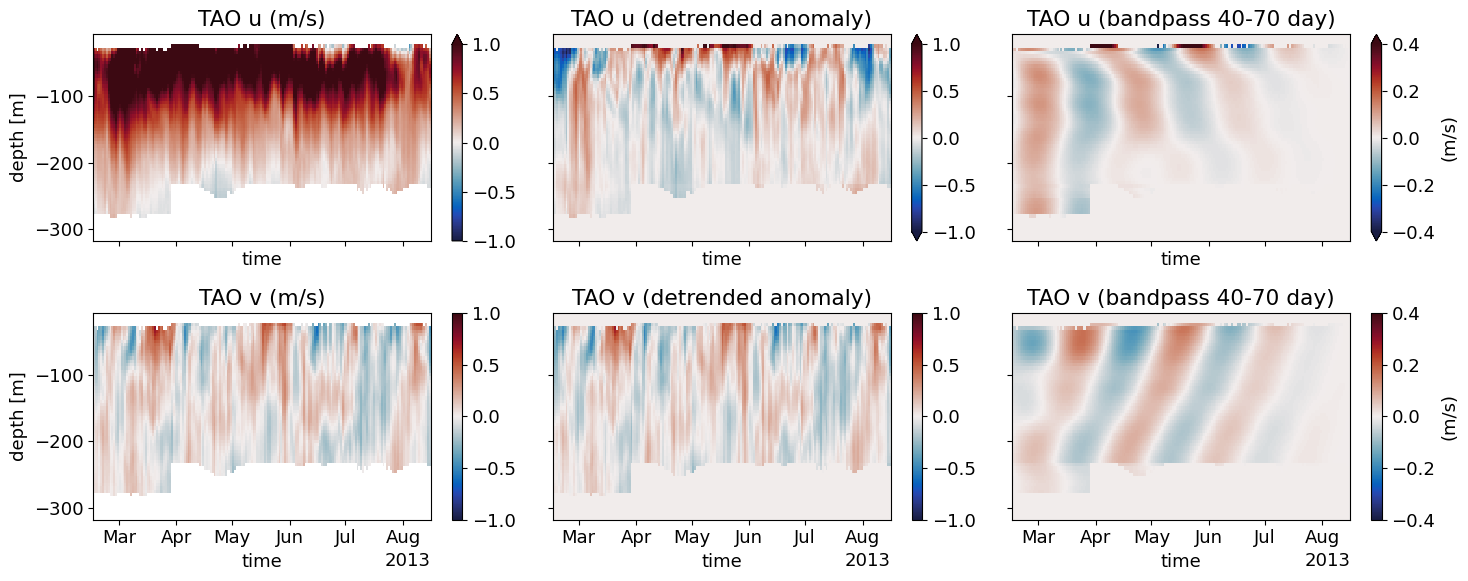

In [72]:
fig, ax = plt.subplots(figsize=(15,6),nrows=2, ncols=3, sharex=True, sharey=True)
dsTAO_mini.u_1205.plot(ax=ax[0,0],x='time',cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
dsTAO_mini.v_1206.plot(ax=ax[1,0],x='time',cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
uvel_detrend.plot(ax=ax[0,1],cmap=cmo.balance,x='time',vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
vvel_detrend.plot(ax=ax[1,1],cmap=cmo.balance,x='time',vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
uvel_bandpass.plot(ax=ax[0,2],cmap=cmo.balance,x='time',vmin=-0.4,vmax=0.4,cbar_kwargs={'label':'(m/s)'})
vvel_bandpass.plot(ax=ax[1,2],cmap=cmo.balance,x='time',vmin=-0.4,vmax=0.4,cbar_kwargs={'label':'(m/s)'})
ax[0,0].set_title('TAO u (m/s)')
ax[1,0].set_title('TAO v (m/s)')
ax[0,1].set_title('TAO u (detrended anomaly)')
ax[1,1].set_title('TAO v (detrended anomaly)')
ax[0,2].set_title('TAO u (bandpass 40-70 day)')
ax[1,2].set_title('TAO v (bandpass 40-70 day)')

ax[0,1].set_ylabel('')
ax[0,2].set_ylabel('')
ax[1,1].set_ylabel('')
ax[1,2].set_ylabel('')

plt.tight_layout() 
fig.savefig(foldername + 'TAO_u_v_spring_bandpass_' + lon_str + '.png',dpi=300)

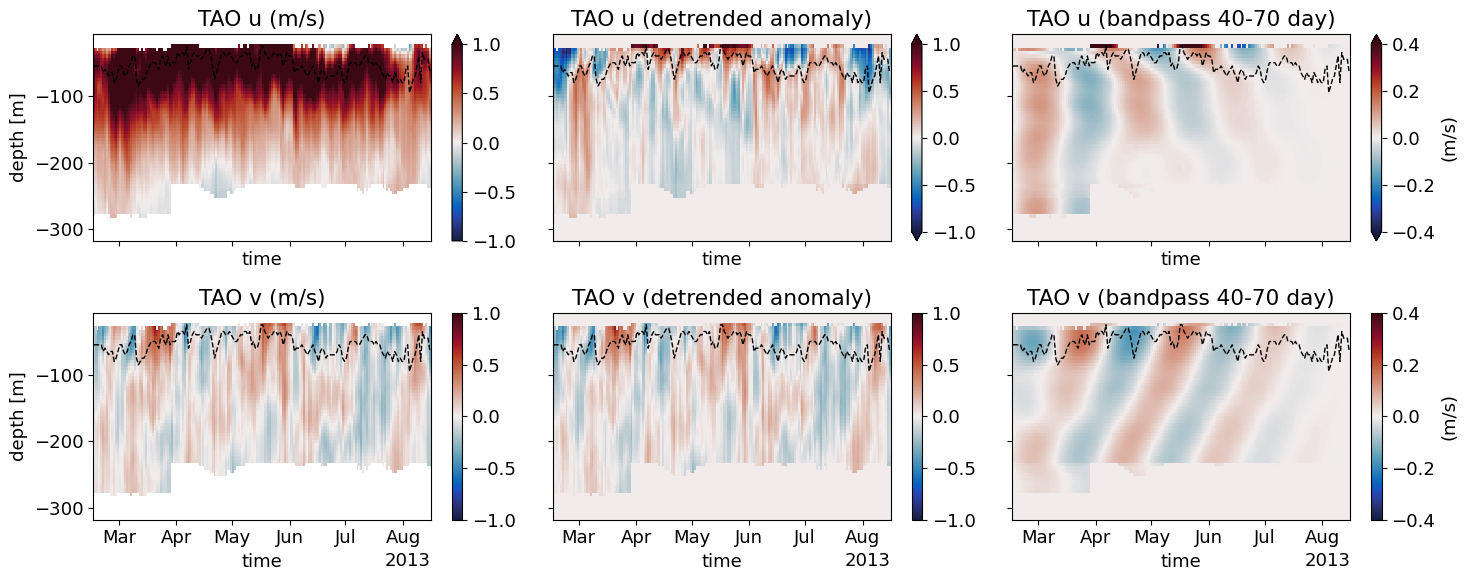

In [73]:
fig, ax = plt.subplots(figsize=(15,6),nrows=2, ncols=3, sharex=True, sharey=True)
dsTAO_mini.u_1205.plot(ax=ax[0,0],x='time',cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
dsTAO_mini.v_1206.plot(ax=ax[1,0],x='time',cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
uvel_detrend.plot(ax=ax[0,1],cmap=cmo.balance,x='time',vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
vvel_detrend.plot(ax=ax[1,1],cmap=cmo.balance,x='time',vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
uvel_bandpass.plot(ax=ax[0,2],cmap=cmo.balance,x='time',vmin=-0.4,vmax=0.4,cbar_kwargs={'label':'(m/s)'})
vvel_bandpass.plot(ax=ax[1,2],cmap=cmo.balance,x='time',vmin=-0.4,vmax=0.4,cbar_kwargs={'label':'(m/s)'})
ax[0,0].set_title('TAO u (m/s)')
ax[1,0].set_title('TAO v (m/s)')
ax[0,1].set_title('TAO u (detrended anomaly)')
ax[1,1].set_title('TAO v (detrended anomaly)')
ax[0,2].set_title('TAO u (bandpass 40-70 day)')
ax[1,2].set_title('TAO v (bandpass 40-70 day)')

ax[0,1].set_ylabel('')
ax[0,2].set_ylabel('')
ax[1,1].set_ylabel('')
ax[1,2].set_ylabel('')

for ax in ax.flatten():
    ax.plot(dsTAO_mini.time, dsTAO_mini.Z[euc_core_depth], 'k', linestyle='--',linewidth=1)

plt.tight_layout() 
fig.savefig(foldername + 'TAO_u_v_spring_bandpass_EUCCore_' + lon_str + '.png',dpi=300)

In [74]:
# filtering out high frequency changes
fs = 1/86400 # sampling rate is 1 hour (86400 seconds per hour)
lowF = (1/70)*fs 
cutoff = np.array([lowF])
order = 4
sos = butter(order, cutoff, 'lowpass', fs=fs, output='sos')

uvel_detrend = detrend(dsTAO_mini.u_1205.squeeze().fillna(0), axis=0)
vvel_detrend = detrend(dsTAO_mini.v_1206.squeeze().fillna(0), axis=0)
uvel_bandpass = sosfiltfilt(sos, uvel_detrend, axis=0)
vvel_bandpass = sosfiltfilt(sos, vvel_detrend, axis=0)

temp = dsTAO_mini.u_1205.squeeze().copy(deep=True) 
temp.data = uvel_bandpass *  ~np.isnan(dsTAO_mini.u_1205.squeeze())
uvel_bandpass = temp
temp = dsTAO_mini.v_1206.squeeze().copy(deep=True)
temp.data = vvel_bandpass *  ~np.isnan(dsTAO_mini.v_1206.squeeze())
vvel_bandpass = temp
temp = dsTAO_mini.u_1205.squeeze().copy(deep=True) 
temp.data = uvel_detrend *  ~np.isnan(dsTAO_mini.u_1205.squeeze())
uvel_detrend = temp
temp = dsTAO_mini.v_1206.squeeze().copy(deep=True)
temp.data = vvel_detrend *  ~np.isnan(dsTAO_mini.v_1206.squeeze())
vvel_detrend = temp


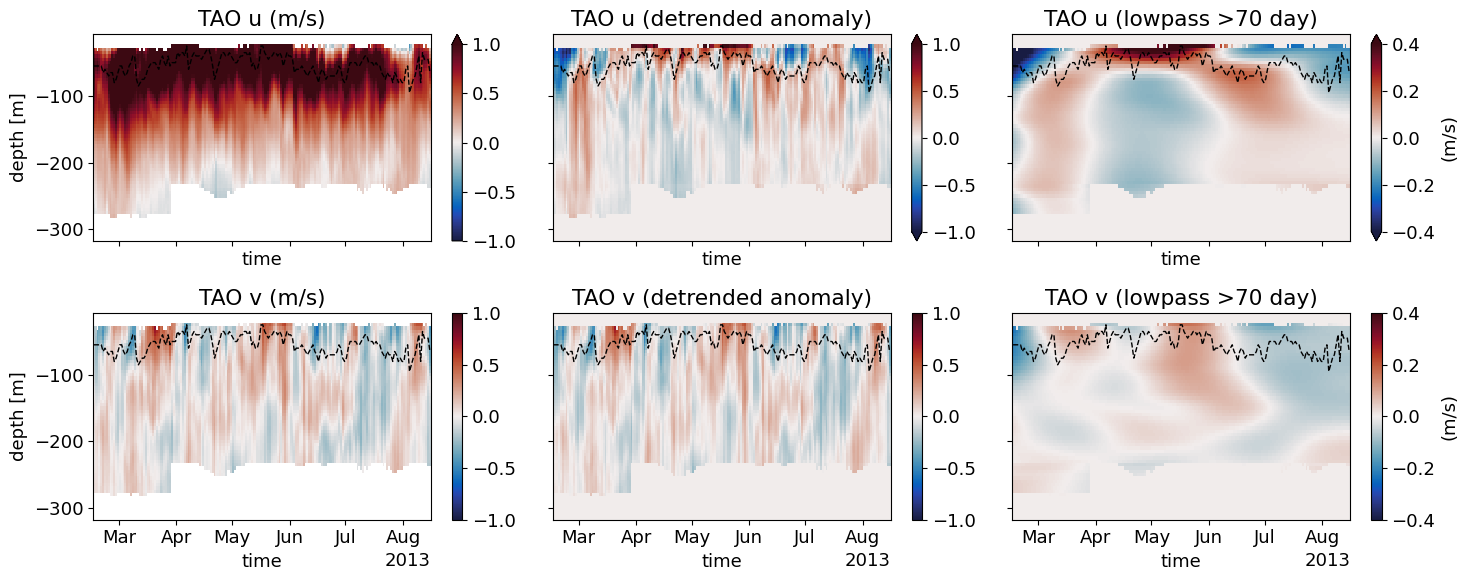

In [75]:
fig, ax = plt.subplots(figsize=(15,6),nrows=2, ncols=3, sharex=True, sharey=True)
dsTAO_mini.u_1205.plot(ax=ax[0,0],x='time',cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
dsTAO_mini.v_1206.plot(ax=ax[1,0],x='time',cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
uvel_detrend.plot(ax=ax[0,1],cmap=cmo.balance,x='time',vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
vvel_detrend.plot(ax=ax[1,1],cmap=cmo.balance,x='time',vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
uvel_bandpass.plot(ax=ax[0,2],cmap=cmo.balance,x='time',vmin=-0.4,vmax=0.4,cbar_kwargs={'label':'(m/s)'})
vvel_bandpass.plot(ax=ax[1,2],cmap=cmo.balance,x='time',vmin=-0.4,vmax=0.4,cbar_kwargs={'label':'(m/s)'})
ax[0,0].set_title('TAO u (m/s)')
ax[1,0].set_title('TAO v (m/s)')
ax[0,1].set_title('TAO u (detrended anomaly)')
ax[1,1].set_title('TAO v (detrended anomaly)')
ax[0,2].set_title('TAO u (lowpass >70 day)')
ax[1,2].set_title('TAO v (lowpass >70 day)')

ax[0,1].set_ylabel('')
ax[0,2].set_ylabel('')
ax[1,1].set_ylabel('')
ax[1,2].set_ylabel('')

for ax in ax.flatten():
    ax.plot(dsTAO_mini.time, dsTAO_mini.Z[euc_core_depth], 'k', linestyle='--',linewidth=1)

plt.tight_layout() 
fig.savefig(foldername + 'TAO_u_v_spring_lowpass_EUCCore_' + lon_str + '.png',dpi=300)

In [76]:
# filtering out high frequency changes
fs = 1/86400 # sampling rate is 1 hour (86400 seconds per hour)
highF = (1/40)*fs 
cutoff = np.array([highF])
order = 4
sos = butter(order, cutoff, 'highpass', fs=fs, output='sos')

uvel_detrend = detrend(dsTAO_mini.u_1205.squeeze().fillna(0), axis=0)
vvel_detrend = detrend(dsTAO_mini.v_1206.squeeze().fillna(0), axis=0)
uvel_bandpass = sosfiltfilt(sos, uvel_detrend, axis=0)
vvel_bandpass = sosfiltfilt(sos, vvel_detrend, axis=0)

temp = dsTAO_mini.u_1205.squeeze().copy(deep=True) 
temp.data = uvel_bandpass *  ~np.isnan(dsTAO_mini.u_1205.squeeze())
uvel_bandpass = temp
temp = dsTAO_mini.v_1206.squeeze().copy(deep=True)
temp.data = vvel_bandpass *  ~np.isnan(dsTAO_mini.v_1206.squeeze())
vvel_bandpass = temp
temp = dsTAO_mini.u_1205.squeeze().copy(deep=True) 
temp.data = uvel_detrend *  ~np.isnan(dsTAO_mini.u_1205.squeeze())
uvel_detrend = temp
temp = dsTAO_mini.v_1206.squeeze().copy(deep=True)
temp.data = vvel_detrend *  ~np.isnan(dsTAO_mini.v_1206.squeeze())
vvel_detrend = temp

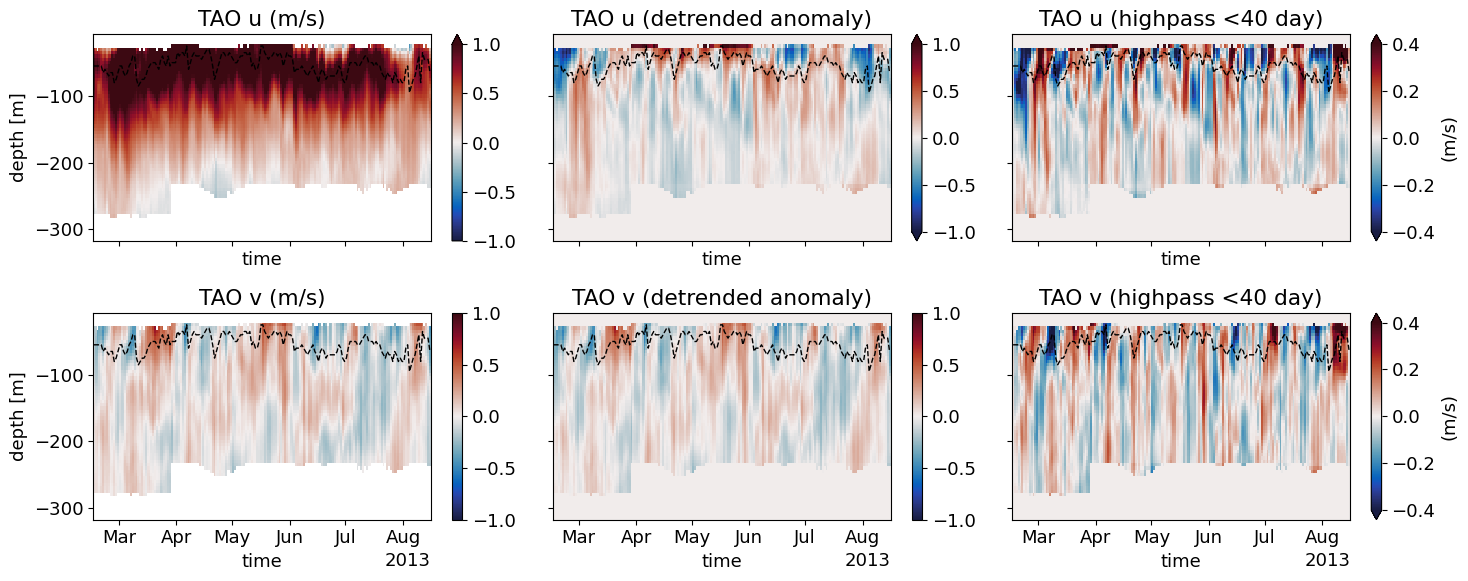

In [77]:
fig, ax = plt.subplots(figsize=(15,6),nrows=2, ncols=3, sharex=True, sharey=True)
dsTAO_mini.u_1205.plot(ax=ax[0,0],x='time',cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
dsTAO_mini.v_1206.plot(ax=ax[1,0],x='time',cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
uvel_detrend.plot(ax=ax[0,1],cmap=cmo.balance,x='time',vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
vvel_detrend.plot(ax=ax[1,1],cmap=cmo.balance,x='time',vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
uvel_bandpass.plot(ax=ax[0,2],cmap=cmo.balance,x='time',vmin=-0.4,vmax=0.4,cbar_kwargs={'label':'(m/s)'})
vvel_bandpass.plot(ax=ax[1,2],cmap=cmo.balance,x='time',vmin=-0.4,vmax=0.4,cbar_kwargs={'label':'(m/s)'})
ax[0,0].set_title('TAO u (m/s)')
ax[1,0].set_title('TAO v (m/s)')
ax[0,1].set_title('TAO u (detrended anomaly)')
ax[1,1].set_title('TAO v (detrended anomaly)')
ax[0,2].set_title('TAO u (highpass <40 day)')
ax[1,2].set_title('TAO v (highpass <40 day)')

ax[0,1].set_ylabel('')
ax[0,2].set_ylabel('')
ax[1,1].set_ylabel('')
ax[1,2].set_ylabel('')

for ax in ax.flatten():
    ax.plot(dsTAO_mini.time, dsTAO_mini.Z[euc_core_depth], 'k', linestyle='--',linewidth=1)

plt.tight_layout() 
fig.savefig(foldername + 'TAO_u_v_spring_highpass_EUCCore_' + lon_str + '.png',dpi=300)

In [78]:
# filtering out high frequency changes
fs = 1/86400 # sampling rate is 1 hour (86400 seconds per hour)
highF = (1/40)*fs #  (1 cycle /40 days) * (1 day/86400 second)
lowF = (1/70)*fs #  (1 cycle /70 days) * (1 day/86400 second)
cutoff = np.array([lowF, highF])
order = 4
sos = butter(order, cutoff, 'bandpass', fs=fs, output='sos')

uvel_detrend = detrend(dsTAO.u_1205.squeeze().fillna(0), axis=0)
vvel_detrend = detrend(dsTAO.v_1206.squeeze().fillna(0), axis=0)
uvel_bandpass = sosfiltfilt(sos, uvel_detrend, axis=0)
vvel_bandpass = sosfiltfilt(sos, vvel_detrend, axis=0)

temp = dsTAO.u_1205.squeeze().copy(deep=True) 
temp.data = uvel_bandpass *  ~np.isnan(dsTAO.u_1205.squeeze())
uvel_bandpass = temp
temp = dsTAO.v_1206.squeeze().copy(deep=True)
temp.data = vvel_bandpass *  ~np.isnan(dsTAO.v_1206.squeeze())
vvel_bandpass = temp
temp = dsTAO.u_1205.squeeze().copy(deep=True) 
temp.data = uvel_detrend *  ~np.isnan(dsTAO.u_1205.squeeze())
uvel_detrend = temp
temp = dsTAO.v_1206.squeeze().copy(deep=True)
temp.data = vvel_detrend *  ~np.isnan(dsTAO.v_1206.squeeze())
vvel_detrend = temp


In [79]:
# euc core depth as the depth of max zonal velocity 
euc_core_depth = dsTAO.u_1205.squeeze().argmax(dim='Z')

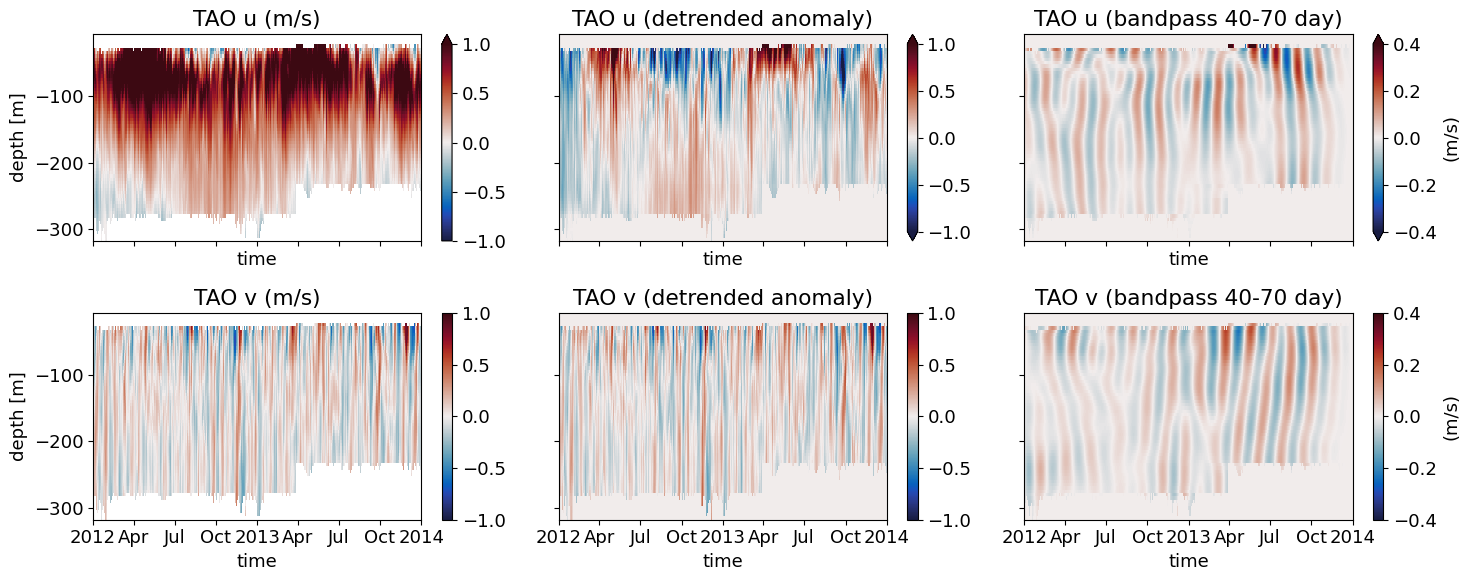

In [80]:
fig, ax = plt.subplots(figsize=(15,6),nrows=2, ncols=3, sharex=True, sharey=True)
dsTAO.u_1205.plot(ax=ax[0,0],x='time',cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
dsTAO.v_1206.plot(ax=ax[1,0],x='time',cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
uvel_detrend.plot(ax=ax[0,1],cmap=cmo.balance,x='time',vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
vvel_detrend.plot(ax=ax[1,1],cmap=cmo.balance,x='time',vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
uvel_bandpass.plot(ax=ax[0,2],cmap=cmo.balance,x='time',vmin=-0.4,vmax=0.4,cbar_kwargs={'label':'(m/s)'})
vvel_bandpass.plot(ax=ax[1,2],cmap=cmo.balance,x='time',vmin=-0.4,vmax=0.4,cbar_kwargs={'label':'(m/s)'})
ax[0,0].set_title('TAO u (m/s)')
ax[1,0].set_title('TAO v (m/s)')
ax[0,1].set_title('TAO u (detrended anomaly)')
ax[1,1].set_title('TAO v (detrended anomaly)')
ax[0,2].set_title('TAO u (bandpass 40-70 day)')
ax[1,2].set_title('TAO v (bandpass 40-70 day)')

ax[0,1].set_ylabel('')
ax[0,2].set_ylabel('')
ax[1,1].set_ylabel('')
ax[1,2].set_ylabel('')
    
plt.tight_layout() 
fig.savefig(foldername + 'TAO_u_v_2013_bandpass_' + lon_str + '.png',dpi=300)

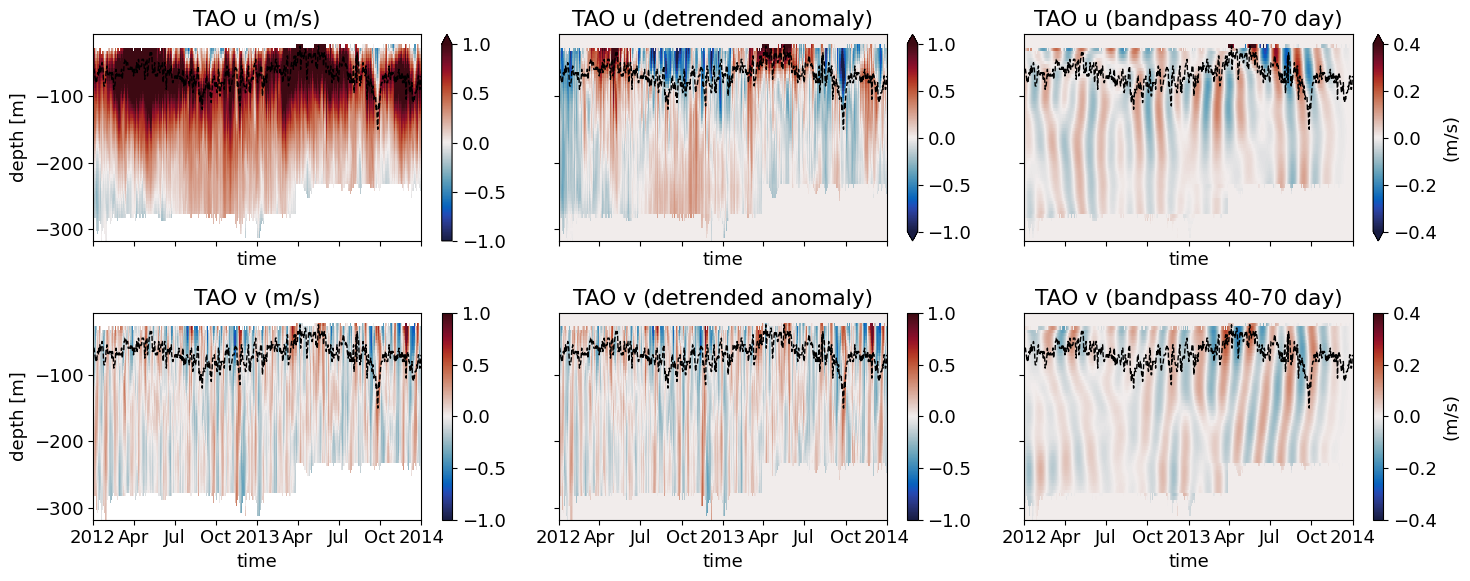

In [81]:
fig, ax = plt.subplots(figsize=(15,6),nrows=2, ncols=3, sharex=True, sharey=True)
dsTAO.u_1205.plot(ax=ax[0,0],x='time',cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
dsTAO.v_1206.plot(ax=ax[1,0],x='time',cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
uvel_detrend.plot(ax=ax[0,1],cmap=cmo.balance,x='time',vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
vvel_detrend.plot(ax=ax[1,1],cmap=cmo.balance,x='time',vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
uvel_bandpass.plot(ax=ax[0,2],cmap=cmo.balance,x='time',vmin=-0.4,vmax=0.4,cbar_kwargs={'label':'(m/s)'})
vvel_bandpass.plot(ax=ax[1,2],cmap=cmo.balance,x='time',vmin=-0.4,vmax=0.4,cbar_kwargs={'label':'(m/s)'})
ax[0,0].set_title('TAO u (m/s)')
ax[1,0].set_title('TAO v (m/s)')
ax[0,1].set_title('TAO u (detrended anomaly)')
ax[1,1].set_title('TAO v (detrended anomaly)')
ax[0,2].set_title('TAO u (bandpass 40-70 day)')
ax[1,2].set_title('TAO v (bandpass 40-70 day)')

ax[0,1].set_ylabel('')
ax[0,2].set_ylabel('')
ax[1,1].set_ylabel('')
ax[1,2].set_ylabel('')

for ax in ax.flatten():
    ax.plot(dsTAO.time, dsTAO.Z[euc_core_depth], 'k', linestyle='--',linewidth=1)
    
plt.tight_layout() 
fig.savefig(foldername + 'TAO_u_v_2013_bandpass_EUCcore_' + lon_str + '.png',dpi=300)

In [82]:
# filtering out high frequency changes
fs = 1/86400 # sampling rate is 1 hour (86400 seconds per hour)
lowF = (1/70)*fs 
cutoff = np.array([lowF])
order = 4
sos = butter(order, cutoff, 'lowpass', fs=fs, output='sos')

uvel_detrend = detrend(dsTAO.u_1205.squeeze().fillna(0), axis=0)
vvel_detrend = detrend(dsTAO.v_1206.squeeze().fillna(0), axis=0)
uvel_bandpass = sosfiltfilt(sos, uvel_detrend, axis=0)
vvel_bandpass = sosfiltfilt(sos, vvel_detrend, axis=0)

temp = dsTAO.u_1205.squeeze().copy(deep=True) 
temp.data = uvel_bandpass *  ~np.isnan(dsTAO.u_1205.squeeze())
uvel_bandpass = temp
temp = dsTAO.v_1206.squeeze().copy(deep=True)
temp.data = vvel_bandpass *  ~np.isnan(dsTAO.v_1206.squeeze())
vvel_bandpass = temp
temp = dsTAO.u_1205.squeeze().copy(deep=True) 
temp.data = uvel_detrend *  ~np.isnan(dsTAO.u_1205.squeeze())
uvel_detrend = temp
temp = dsTAO.v_1206.squeeze().copy(deep=True)
temp.data = vvel_detrend *  ~np.isnan(dsTAO.v_1206.squeeze())
vvel_detrend = temp

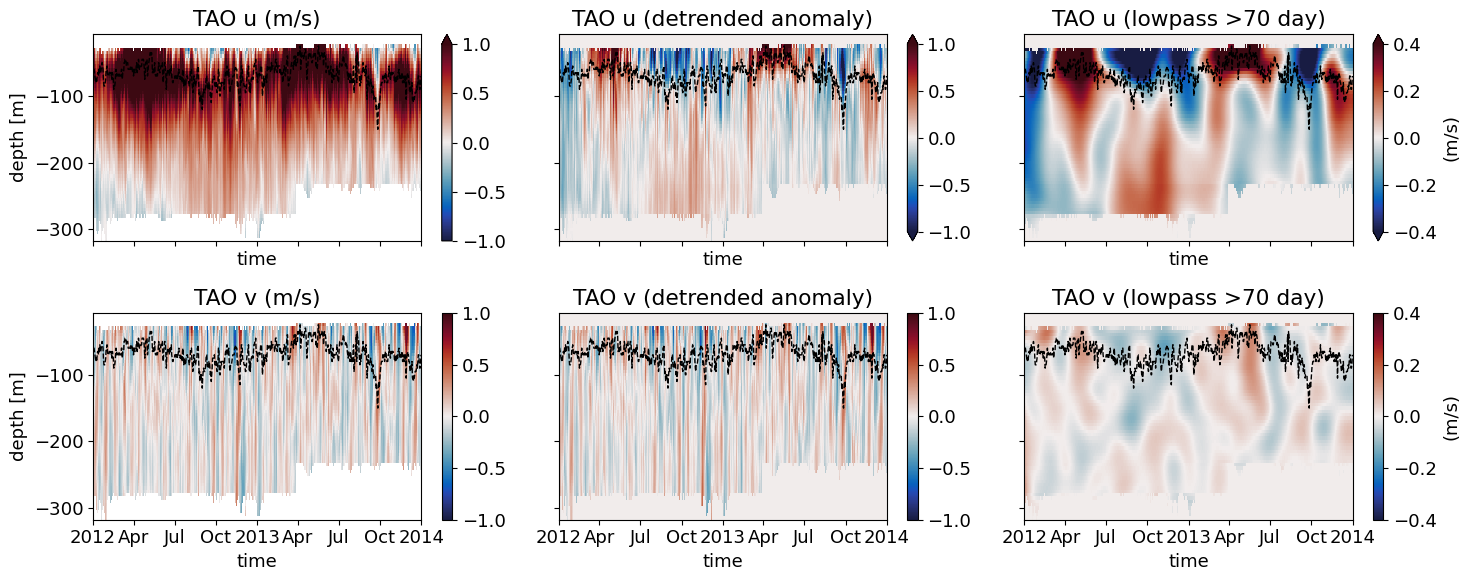

In [83]:
fig, ax = plt.subplots(figsize=(15,6),nrows=2, ncols=3, sharex=True, sharey=True)
dsTAO.u_1205.plot(ax=ax[0,0],x='time',cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
dsTAO.v_1206.plot(ax=ax[1,0],x='time',cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
uvel_detrend.plot(ax=ax[0,1],cmap=cmo.balance,x='time',vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
vvel_detrend.plot(ax=ax[1,1],cmap=cmo.balance,x='time',vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
uvel_bandpass.plot(ax=ax[0,2],cmap=cmo.balance,x='time',vmin=-0.4,vmax=0.4,cbar_kwargs={'label':'(m/s)'})
vvel_bandpass.plot(ax=ax[1,2],cmap=cmo.balance,x='time',vmin=-0.4,vmax=0.4,cbar_kwargs={'label':'(m/s)'})
ax[0,0].set_title('TAO u (m/s)')
ax[1,0].set_title('TAO v (m/s)')
ax[0,1].set_title('TAO u (detrended anomaly)')
ax[1,1].set_title('TAO v (detrended anomaly)')
ax[0,2].set_title('TAO u (lowpass >70 day)')
ax[1,2].set_title('TAO v (lowpass >70 day)')

ax[0,1].set_ylabel('')
ax[0,2].set_ylabel('')
ax[1,1].set_ylabel('')
ax[1,2].set_ylabel('')

for ax in ax.flatten():
    ax.plot(dsTAO.time, dsTAO.Z[euc_core_depth], 'k', linestyle='--',linewidth=1)
    
plt.tight_layout() 
fig.savefig(foldername + 'TAO_u_v_2013_lowpass_EUCcore_' + lon_str + '.png',dpi=300)

In [84]:
# filtering out high frequency changes
fs = 1/86400 # sampling rate is 1 hour (86400 seconds per hour)
lowF = (1/40)*fs 
cutoff = np.array([highF])
order = 4
sos = butter(order, cutoff, 'highpass', fs=fs, output='sos')

uvel_detrend = detrend(dsTAO.u_1205.squeeze().fillna(0), axis=0)
vvel_detrend = detrend(dsTAO.v_1206.squeeze().fillna(0), axis=0)
uvel_bandpass = sosfiltfilt(sos, uvel_detrend, axis=0)
vvel_bandpass = sosfiltfilt(sos, vvel_detrend, axis=0)

temp = dsTAO.u_1205.squeeze().copy(deep=True) 
temp.data = uvel_bandpass *  ~np.isnan(dsTAO.u_1205.squeeze())
uvel_bandpass = temp
temp = dsTAO.v_1206.squeeze().copy(deep=True)
temp.data = vvel_bandpass *  ~np.isnan(dsTAO.v_1206.squeeze())
vvel_bandpass = temp
temp = dsTAO.u_1205.squeeze().copy(deep=True) 
temp.data = uvel_detrend *  ~np.isnan(dsTAO.u_1205.squeeze())
uvel_detrend = temp
temp = dsTAO.v_1206.squeeze().copy(deep=True)
temp.data = vvel_detrend *  ~np.isnan(dsTAO.v_1206.squeeze())
vvel_detrend = temp

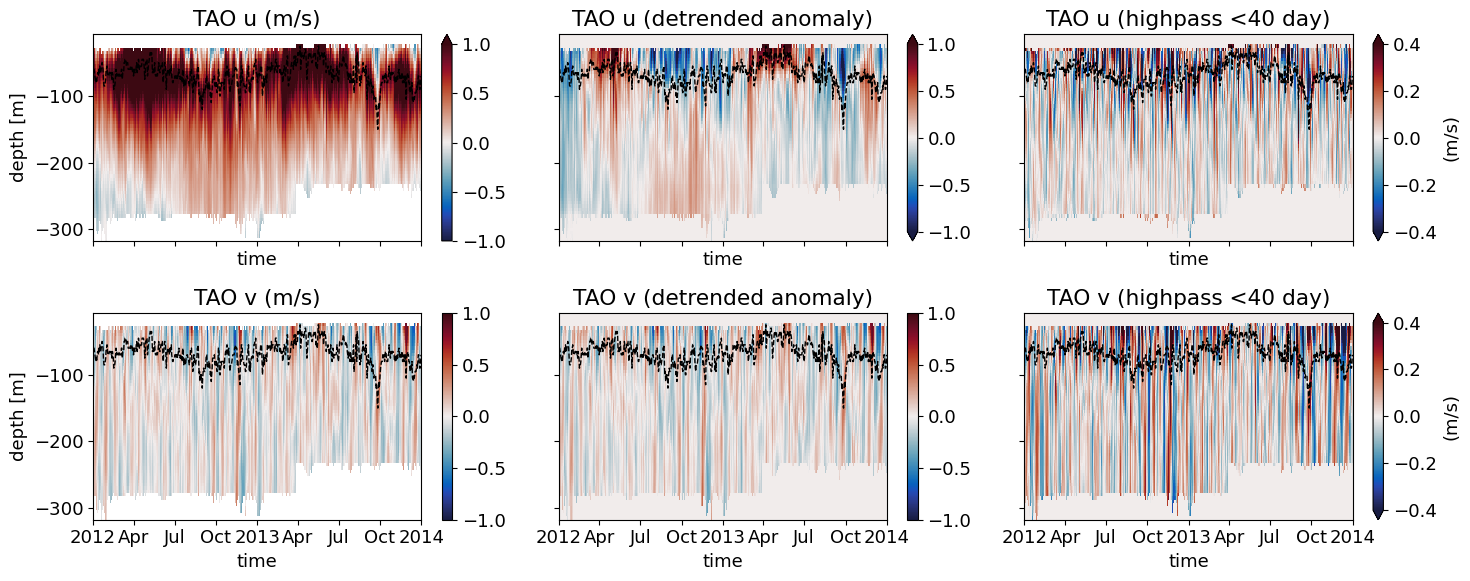

In [85]:
fig, ax = plt.subplots(figsize=(15,6),nrows=2, ncols=3, sharex=True, sharey=True)
dsTAO.u_1205.plot(ax=ax[0,0],x='time',cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
dsTAO.v_1206.plot(ax=ax[1,0],x='time',cmap=cmo.balance,vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
uvel_detrend.plot(ax=ax[0,1],cmap=cmo.balance,x='time',vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
vvel_detrend.plot(ax=ax[1,1],cmap=cmo.balance,x='time',vmin=-1.0,vmax=1.0,cbar_kwargs={'label':''})
uvel_bandpass.plot(ax=ax[0,2],cmap=cmo.balance,x='time',vmin=-0.4,vmax=0.4,cbar_kwargs={'label':'(m/s)'})
vvel_bandpass.plot(ax=ax[1,2],cmap=cmo.balance,x='time',vmin=-0.4,vmax=0.4,cbar_kwargs={'label':'(m/s)'})
ax[0,0].set_title('TAO u (m/s)')
ax[1,0].set_title('TAO v (m/s)')
ax[0,1].set_title('TAO u (detrended anomaly)')
ax[1,1].set_title('TAO v (detrended anomaly)')
ax[0,2].set_title('TAO u (highpass <40 day)')
ax[1,2].set_title('TAO v (highpass <40 day)')

ax[0,1].set_ylabel('')
ax[0,2].set_ylabel('')
ax[1,1].set_ylabel('')
ax[1,2].set_ylabel('')

for ax in ax.flatten():
    ax.plot(dsTAO.time, dsTAO.Z[euc_core_depth], 'k', linestyle='--',linewidth=1)
    
plt.tight_layout() 
fig.savefig(foldername + 'TAO_u_v_2013_highpass_EUCcore_' + lon_str + '.png',dpi=300)

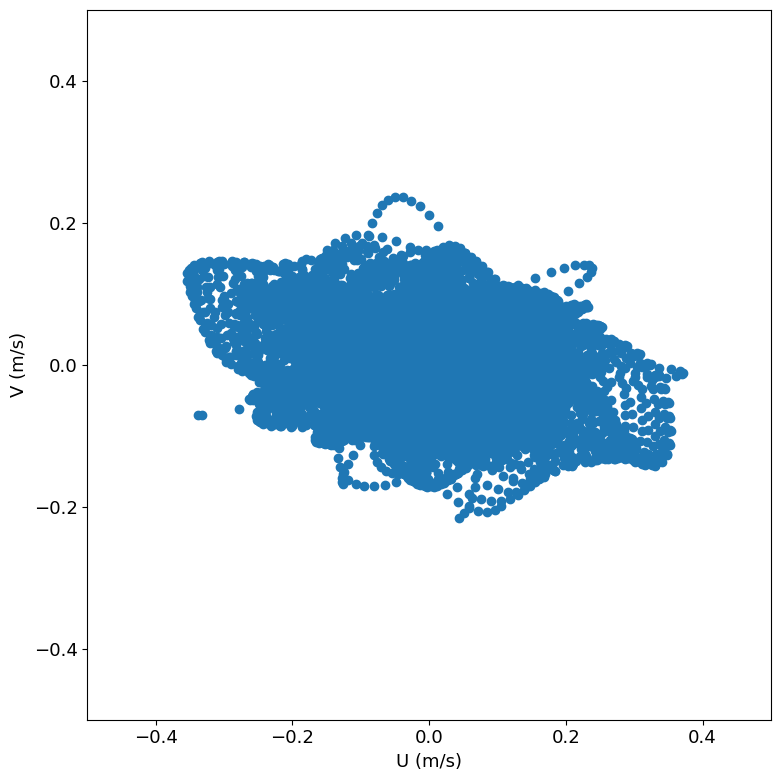

In [143]:
fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(uvel_bandpass,vvel_bandpass)
ax.set_xlabel('U (m/s)')
ax.set_ylabel('V (m/s)')
ax.set_xlim(-0.5,0.5)
ax.set_ylim(-0.5,0.5)
plt.tight_layout()
fig.savefig(foldername + 'TAO_u_v_scatter_2013.png',dpi=300)

### Load TAO U and V

In [28]:
TAO_ADCP_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO = xr.open_dataset(TAO_ADCP_file)

In [29]:
dsTAO['depth'] = -1*dsTAO.depth
dsTAO = dsTAO.sel(time=slice('2012-09-01','2013-06-30')) # subset to sep 2012, apr 2013
dsTAO['u_1205'] = dsTAO.u_1205/100 # convert from cm/s to m/s
dsTAO['v_1206'] = dsTAO.v_1206/100 # convert from cm/s to m/s

In [30]:
dsTAO

<xarray.Dataset> Size: 303kB
Dimensions:  (time: 303, depth: 62, lat: 1, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2012-09-01T12:00:00 ... 2013-06-30T12:...
  * depth    (depth) float32 248B -10.0 -15.0 -20.0 ... -305.0 -310.0 -315.0
  * lat      (lat) float32 4B 0.0
  * lon      (lon) float32 4B 190.0
Data variables:
    u_1205   (time, depth, lat, lon) float32 75kB nan nan nan ... nan nan nan
    QU_5205  (time, depth, lat, lon) float32 75kB ...
    v_1206   (time, depth, lat, lon) float32 75kB nan nan nan ... nan nan nan
    QV_5206  (time, depth, lat, lon) float32 75kB ...
Attributes:
    platform_code:                0n170w
    site_code:                    0n170w
    wmo_platform_code:            51010
    array:                        TAO/TRITON
    Request_for_acknowledgement:  If you use these data in publications or pr...
    Data_Source:                  Global Tropical Moored Buoy Array Project O...
    File_info:                    Contact: Dai.C.McClurg@noaa.gov
    missing_value:                1e+35
    _FillValue:                   1e+35
    CREATION_DATE:                09:58 14-AUG-2024

In [31]:
# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'depth':'Z','lat':'YC','lon':'XG'})
tpose_U_noTAO = ds_tpose_noTAO.UVEL.interp_like(dsTAO.u_1205).compute().squeeze()
tpose_U_TAO = ds_tpose_TAO.UVEL.interp_like(dsTAO.u_1205).compute().squeeze()
# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'XG':'XC','YC':'YG'})
tpose_V_noTAO = ds_tpose_noTAO.VVEL.interp_like(dsTAO.v_1206).compute().squeeze()
tpose_V_TAO = ds_tpose_TAO.VVEL.interp_like(dsTAO.v_1206).compute().squeeze()

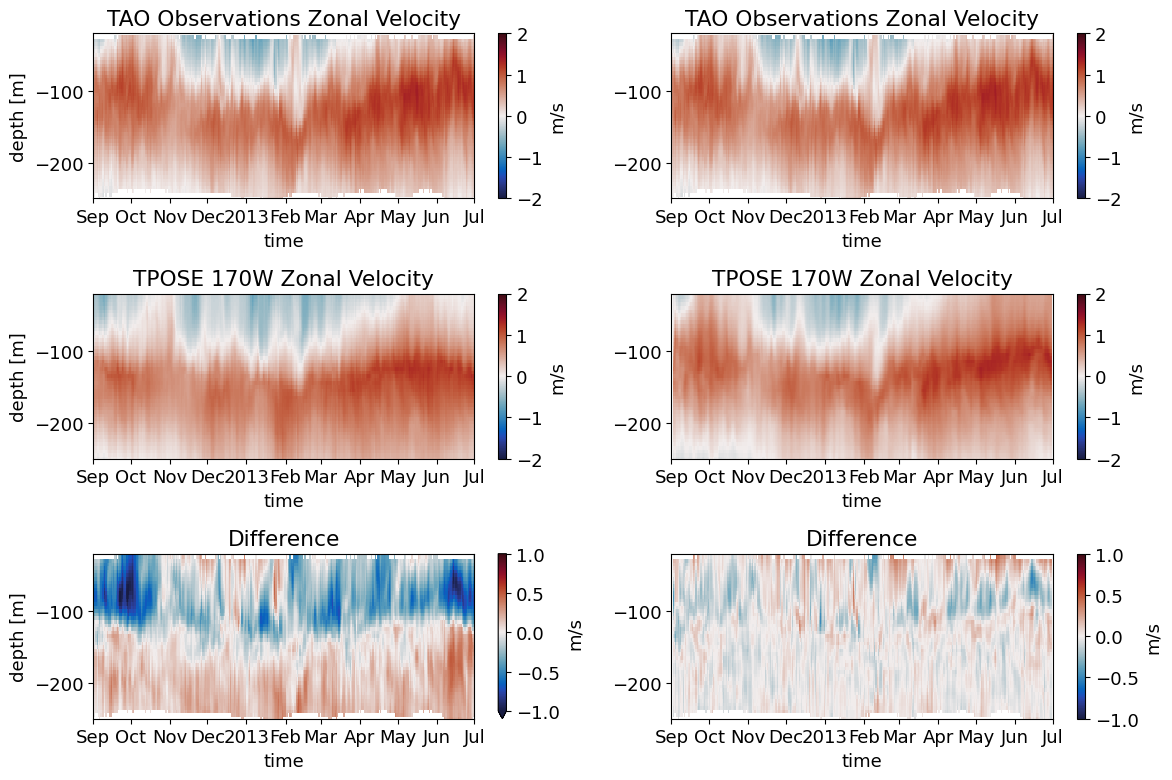

In [32]:
fig, ax = plt.subplots(figsize=(12,8),nrows=3,ncols=2)
dsTAO.u_1205.plot(ax=ax[0,0],cmap=cmo.balance,vmin=-2,vmax=2,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[0,0].set_title('TAO Observations Zonal Velocity')
ax[0,0].set_ylim(-250,-20)
tpose_U_noTAO.plot(ax=ax[1,0],cmap=cmo.balance,vmin=-2,vmax=2,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[1,0].set_title('TPOSE ' + lon_str + 'W Zonal Velocity')
ax[1,0].set_ylim(-250,-20)
(tpose_U_noTAO - dsTAO.u_1205).plot(ax=ax[2,0],cmap=cmo.balance,vmin=-1,vmax=1,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[2,0].set_title('Difference')
ax[2,0].set_ylim(-250,-20)

dsTAO.u_1205.plot(ax=ax[0,1],cmap=cmo.balance,vmin=-2,vmax=2,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[0,1].set_title('TAO Observations Zonal Velocity')
ax[0,1].set_ylabel('')
ax[0,1].set_ylim(-250,-20)
tpose_U_TAO.plot(ax=ax[1,1],cmap=cmo.balance,vmin=-2,vmax=2,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[1,1].set_title('TPOSE ' + lon_str + 'W Zonal Velocity')
ax[1,1].set_ylim(-250,-20)
ax[1,1].set_ylabel('')
(tpose_U_TAO - dsTAO.u_1205).plot(ax=ax[2,1],cmap=cmo.balance,vmin=-1,vmax=1,x='time',y='Z',cbar_kwargs={'label':'m/s'})
ax[2,1].set_title('Difference')
ax[2,1].set_ylim(-250,-20)
ax[2,1].set_ylabel('')
plt.tight_layout()
fig.savefig(foldername+'U_' + lon_str + 'W_diffTAOassim_jun2013.png')

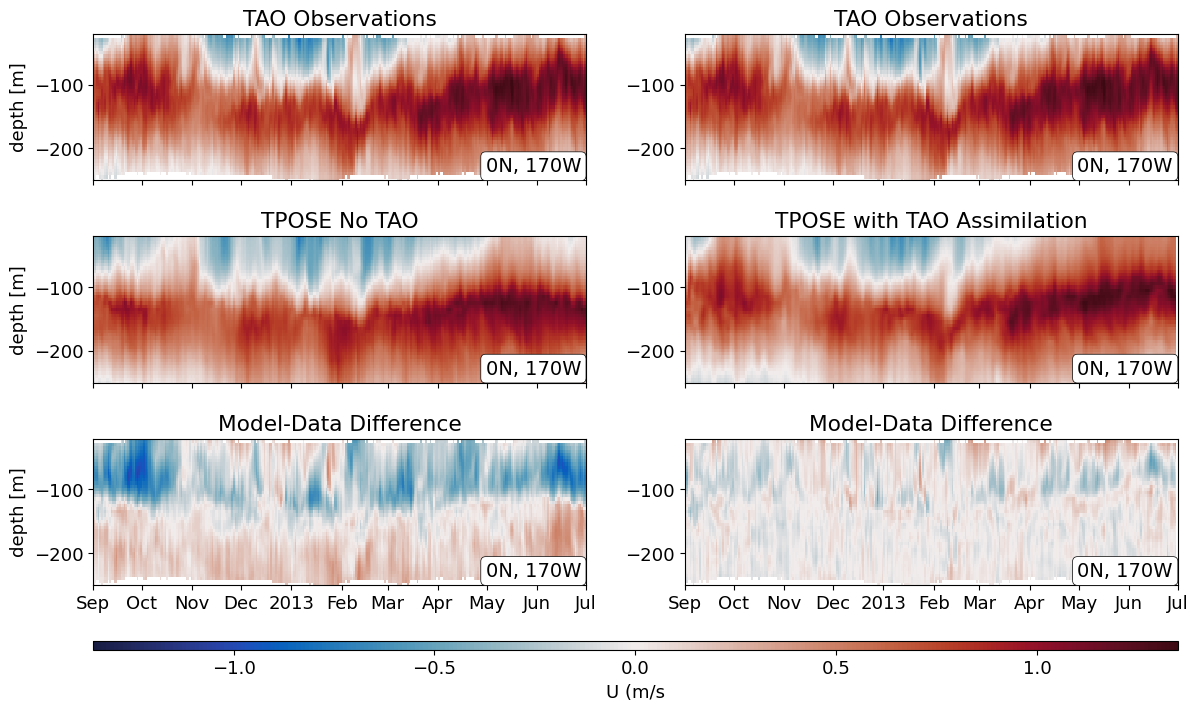

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 8))

gs = gridspec.GridSpec(
    4, 2,
    height_ratios=[1, 1, 1, 0.06],
    hspace=0.5,
    wspace=0.2
)

# Create axes with shared x within each column
ax = np.empty((3, 2), dtype=object)

ax[0,0] = fig.add_subplot(gs[0,0])
ax[1,0] = fig.add_subplot(gs[1,0], sharex=ax[0,0])
ax[2,0] = fig.add_subplot(gs[2,0], sharex=ax[0,0])

ax[0,1] = fig.add_subplot(gs[0,1])
ax[1,1] = fig.add_subplot(gs[1,1], sharex=ax[0,1])
ax[2,1] = fig.add_subplot(gs[2,1], sharex=ax[0,1])

vmin, vmax = -1.35, 1.35

# ----- Left column -----
mappable = dsTAO.u_1205.plot(
    ax=ax[0,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
tpose_U_noTAO.plot(
    ax=ax[1,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_U_noTAO - dsTAO.u_1205).plot(
    ax=ax[2,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)

# ----- Right column -----
dsTAO.u_1205.plot(
    ax=ax[0,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
tpose_U_TAO.plot(
    ax=ax[1,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_U_TAO - dsTAO.u_1205).plot(
    ax=ax[2,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)

title = '0N, ' + lon_str + 'W'
# Remove titles everywhere
for i in range(3):
    for j in range(2):
        ax[i,j].set_ylim(-250, -20)
        ax[i,j].set_xlabel('')
        ax[i, j].text(
        0.99, 0.16, title,
        transform=ax[i, j].transAxes,
        ha='right', va='top',
        fontsize=14,
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor='white',
            edgecolor='k',
            linewidth=0.5,
            alpha=1.0
        )
    )

# Remove y-labels on right column
for i in range(3):
    ax[i,1].set_ylabel('')

# Remove x tick labels except bottom row
for j in range(2):
    ax[0,j].tick_params(labelbottom=False)
    ax[1,j].tick_params(labelbottom=False)


ax[0,0].set_title('TAO Observations')
ax[1,0].set_title('TPOSE No TAO')
ax[2,0].set_title('Model-Data Difference')
ax[0,1].set_title('TAO Observations')
ax[1,1].set_title('TPOSE with TAO Assimilation')
ax[2,1].set_title('Model-Data Difference')

# ----- Colorbar -----
cax = fig.add_subplot(gs[3, :])
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_label('U (m/s')

fig.savefig(foldername+'U_' + lon_str + 'W_diffTAOassim_OSM_jun2013.png')

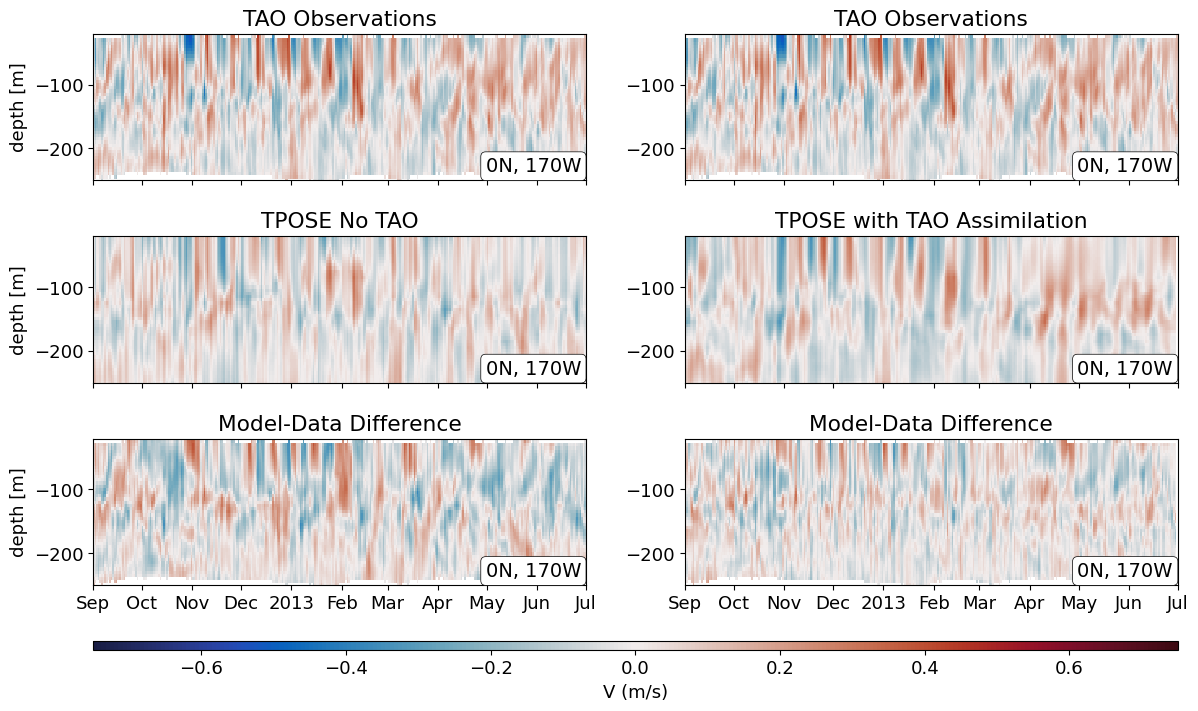

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 8))

gs = gridspec.GridSpec(
    4, 2,
    height_ratios=[1, 1, 1, 0.06],
    hspace=0.5,
    wspace=0.2
)

# Create axes with shared x within each column
ax = np.empty((3, 2), dtype=object)

ax[0,0] = fig.add_subplot(gs[0,0])
ax[1,0] = fig.add_subplot(gs[1,0], sharex=ax[0,0])
ax[2,0] = fig.add_subplot(gs[2,0], sharex=ax[0,0])

ax[0,1] = fig.add_subplot(gs[0,1])
ax[1,1] = fig.add_subplot(gs[1,1], sharex=ax[0,1])
ax[2,1] = fig.add_subplot(gs[2,1], sharex=ax[0,1])

vmin, vmax = -0.75, 0.75

# ----- Left column -----
mappable = dsTAO.v_1206.plot(
    ax=ax[0,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
tpose_V_noTAO.plot(
    ax=ax[1,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_V_noTAO - dsTAO.v_1206).plot(
    ax=ax[2,0], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)

# ----- Right column -----
dsTAO.v_1206.plot(
    ax=ax[0,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
tpose_V_TAO.plot(
    ax=ax[1,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)
(tpose_V_TAO - dsTAO.v_1206).plot(
    ax=ax[2,1], cmap=cmo.balance,
    vmin=vmin, vmax=vmax,
    x='time', y='Z',
    add_colorbar=False
)

# Remove titles everywhere
title = '0N, ' + lon_str + 'W'
# Remove titles everywhere
for i in range(3):
    for j in range(2):
        ax[i,j].set_ylim(-250, -20)
        ax[i,j].set_xlabel('')
        ax[i, j].text(
        0.99, 0.16, title,
        transform=ax[i, j].transAxes,
        ha='right', va='top',
        fontsize=14,
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor='white',
            edgecolor='k',
            linewidth=0.5,
            alpha=1.0
        )
    )
# Remove y-labels on right column
for i in range(3):
    ax[i,1].set_ylabel('')

# Remove x tick labels except bottom row
for j in range(2):
    ax[0,j].tick_params(labelbottom=False)
    ax[1,j].tick_params(labelbottom=False)

ax[0,0].set_title('TAO Observations')
ax[1,0].set_title('TPOSE No TAO')
ax[2,0].set_title('Model-Data Difference')
ax[0,1].set_title('TAO Observations')
ax[1,1].set_title('TPOSE with TAO Assimilation')
ax[2,1].set_title('Model-Data Difference')

# ----- Colorbar -----
cax = fig.add_subplot(gs[3, :])
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_label('V (m/s)')

fig.savefig(foldername+'V_' + lon_str + 'W_diffTAOassim_OSM_jun2013.png')


In [81]:
client.shutdown()
cluster.close()
client.close()